**Implement 4 different greedy pursuit algorithm: MP, OMP, SP and CoSaMP**

# Part 1

Recover the $\mathbf{x}$ from Assignment I using the four different greedy algorithms. Time all the recover solution so far and compare.

In [1]:
import time

# Import the necessaries libraries
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Import code from HW1
from HW1 import (
    DATA_FILE,
    load_data,
    check_solution,
    solve_l0_exhaustive,
    solve_l1_linear_programming,
)

In [2]:
# Load the data
data = load_data(DATA_FILE)

print("Data loaded successfully. The shape of the matrices are:")
print(f"Af: {data['Af'].shape}, Ar: {data['Ar'].shape}, yf: {data['yf'].shape}, yr: {data['yr'].shape}")

Data loaded successfully. The shape of the matrices are:
Af: (25, 100), Ar: (25, 100), yf: (25, 1), yr: (25, 1)


## Matching Pursuit (MP)

The following is my intepretation of the algorithm.

We have a measurement vector $\mathbf{y}$, sensing matrix $\mathbf{A}=[\mathbf{a_1}, \mathbf{a_2}, ..., \mathbf{a_N}]$ where $\mathbf{a_i}$ is the $i^{th}$ column vector.
The problem is to find $\mathbf{x}$ where $\mathbf{y}=\mathbf{Ax}$.

**The Algorithm**

We start with an initial guess for $\mathbf{x}$, which we will denote $\mathbf{\hat{x}}=\mathbf{0}$. 

The residual vector of the guess $\mathbf{r}=\mathbf{y}-\mathbf{A\hat{x}} = \mathbf{y}$. 

The task is too find a sparse guess that minimize the norm of the residual.

The signal is a linear combination of the column vector,

$$\mathbf{\hat{y}} = \sum_{i=1}^{N}\mathbf{a_i}x_i$$

To reduce the error, we greedily pick the column vector that is the closest in direction to the current residual vector. Suppose it is $\mathbf{a_j}$,

$$j = \mathrm{argmax}_i|\langle\mathbf{a_i r} \rangle|.$$

The $j^{th}$ elemnt of $\hat{x}$, $x_j$, is added an amount as follow,

$$c = \frac{\langle\mathbf{a_i r} \rangle}{\|\mathbf{a_j}\|^2_2}.$$

After this the residual vector is updated 

$$\mathbf{r}_{new} = \mathbf{r}_{old} - c\mathbf{a_j}.$$

![](image.png)

Repeat the above procedure until residual is within a threshold.

In [3]:
# This is the implementation of the matching pursuit algorithm
def solve_matching_pursuit(A, y, max_iter=10000, tol=1e-6):
    """
    Solves the sparse recovery problem using the Matching Pursuit algorithm.

    Parameters:
    A (numpy.ndarray): The measurement matrix.
    y (numpy.ndarray): The measurement vector.

    Returns:
    numpy.ndarray: The recovered sparse signal.
    """
    # Initialize the residual and the solution
    residual = y.copy().flatten()
    x = np.zeros(A.shape[1])
    
    # Loop until the residual is small enough
    for _ in range(max_iter):
        if np.linalg.norm(residual) <= tol:
            break
        correlations = A.T @ residual
        idx = np.argmax(np.abs(correlations))
        alpha = (correlations[idx] / (A[:, idx] @ A[:, idx]))
        x[idx] += alpha
        residual -= alpha * A[:, idx]

    return x

In [4]:
# Test the mathching pursuit algorithm on the provided data
x_mp_f = solve_matching_pursuit(data['Af'], data['yf'])
x_mp_r = solve_matching_pursuit(data['Ar'], data['yr'])

# Check the solutions
if check_solution(data['Af'], x_mp_f, data['yf']):
    print("Found a valid solution for the forward problem using Matching Pursuit using matrix Af.")
    print(x_mp_f)

if check_solution(data['Ar'], x_mp_r, data['yr']):
    print("Found a valid solution for the reverse problem using Matching Pursuit using matrix Ar.")
    print(x_mp_r)

Found a valid solution for the forward problem using Matching Pursuit using matrix Af.
[ 0.          0.          4.99999933  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          2.99999994  0.          0.
  0.          0.          0.          0.          0.          0.
  0.         39.99999836  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0

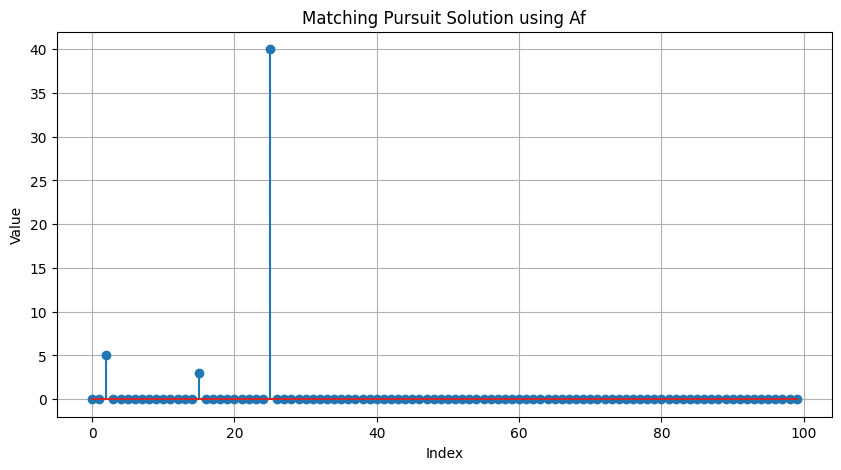

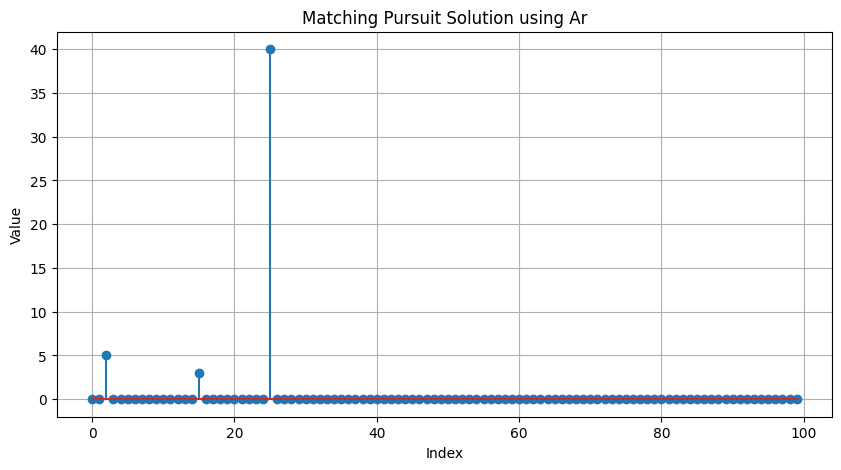

In [5]:
# Let's make a function to plot the results, since we didn't write one in HW1
def plot_solution(x, title):
    plt.figure(figsize=(10, 5))
    plt.stem(x)
    plt.title(title)
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.grid()
    plt.show()

# Plot the solutions
plot_solution(x_mp_f, "Matching Pursuit Solution using Af")
plot_solution(x_mp_r, "Matching Pursuit Solution using Ar")

## Orthogonal Matching Pursuit (OMP)

MP picks column one by one, and it can pick one column multiple because it doesn't re-adjust its previous coefficients. OMP improves on this by ensuring that once a column is picked, the new residual is perpendicular (orthogonal) to every column in the current set.

**The Algorithm**

*Initialization.* Similar to MP.

*Find closest matching column.* Find the closest matching column similar to MP, this columns is added to the *Support Set*. 

*Update the element in $\hat{\mathbf{x}}$.* This is where OMP differs from MP. Instead of adjusting just one coefficient, OMP perform a Least Square fit using all the columns in the Support Set simultaneously.

Let $\mathcal{S}$ be the Support Set. Then OMP find least square solution to 
$$\mathbf{y}_{\mathcal{S}}=\mathbf{A}_{\mathcal{S}}\hat{\mathbf{x}}_{\mathcal{S}}.$$

*Update residual.* Update the residual
$$\mathbf{r} = \mathbf{y} - \mathbf{A}_{\mathcal{S}}\hat{\mathbf{x}}_{\mathcal{S}}$$

Repeat until residual is within threshold.

In [6]:
# Implementation of the orthogonal matching pursuit algorithm
def solve_orthogonal_matching_pursuit(A, y, max_iter=10000, tol=1e-6):
    """
    Solves the sparse recovery problem using the Orthogonal Matching Pursuit algorithm.

    Parameters:
    A (numpy.ndarray): The measurement matrix.
    y (numpy.ndarray): The measurement vector.

    Returns:
    numpy.ndarray: The recovered sparse signal.
    """
    residual = y.copy().flatten()
    x = np.zeros(A.shape[1])
    support = []

    for _ in range(max_iter):
        if np.linalg.norm(residual) <= tol:
            break
        correlations = A.T @ residual
        idx = np.argmax(np.abs(correlations))
        support.append(idx)
        A_support = A[:, support]
        x_support, _, _, _ = np.linalg.lstsq(A_support, y.flatten(), rcond=None)
        residual = y.flatten() - A_support @ x_support

    x[support] = x_support
    return x

In [7]:
# Test the orthogonal matching pursuit algorithm on the provided data
x_omp_f = solve_orthogonal_matching_pursuit(data['Af'], data['yf'])
x_omp_r = solve_orthogonal_matching_pursuit(data['Ar'], data['yr'])
# Check the solutions
if check_solution(data['Af'], x_omp_f, data['yf']):
    print("Found a valid solution for the forward problem using Orthogonal Matching Pursuit using matrix Af.")
    print(x_omp_f)
if check_solution(data['Ar'], x_omp_r, data['yr']):
    print("Found a valid solution for the reverse problem using Orthogonal Matching Pursuit using matrix Ar.")
    print(x_omp_r)                                   

Found a valid solution for the forward problem using Orthogonal Matching Pursuit using matrix Af.
[ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
Found a valid solution for the reverse problem using Orthogonal Matching Pursuit using matrix Ar.
[ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.

## Subspace Pursuit

While MP and OMP doesn't remove a column once it has been picked, SP can removed a column if better columns are found.

**The Algorithm**

*Initialization.* Like MP and OMP, with an additional support set $\mathcal{S}=\varnothing$.

*Find closest matching column.* Like MP and OMP, but find $|\mathcal{S}|$ closest columns.

$$\mathcal{J} = \{ \text{indices of } S \text{ largest } |\langle \mathbf{a}_i, \mathbf{r} \rangle| \}$$

*Merge and prune.* Merge the best columns found in previous step with the current support set.

$$\mathcal{T} = \mathcal{S} \cup \mathcal{J}$$

Perform a Least Squares fit using all columns in the pool $\mathcal{T}$ against the original $\mathbf{y}$:
$$\hat{\mathbf{x}}_{\mathcal{T}} = \text{argmin} \| \mathbf{y} - \mathbf{A}_{\mathcal{T}} \mathbf{x} \|_2$$

Prune the set $\mathcal{T}$ bach to $S$ element based on the coefficients in $\hat{\mathbf{x}}_{\mathcal{T}}$. Keep $S$ element with the largest absolute value coefficients. 

$$\mathcal{S}_{new} = \{ \text{indices of } S \text{ largest elements in } |\hat{\mathbf{x}}_{\mathcal{T}}| \}$$

*Update the guess.* Update the guess based on the $S$ elements with the biggest coefficients from previous step.

*Update the residual.* Calculate the new residual using the pruned support:
$$\mathbf{r} = \mathbf{y} - \mathbf{A}_{\mathcal{S}_{new}} \hat{\mathbf{x}}_{\mathcal{S}_{new}}.$$

Repeat until the residual is within threshold or converge to a value.

In [8]:
# Implementation of the SP algorithm

def solve_subspace_pursuit(A, y, S, max_iter=10000, tol=1e-6):
    y = y.flatten()
    N = A.shape[1]
    residual = y.copy()
    
    # Initial support: S largest correlations
    correlations = np.abs(A.T @ y)
    support = []
    
    for _ in range(max_iter):
        # Step 1: Identify S new candidates from current residual
        new_correlations = np.abs(A.T @ residual)
        new_indices = np.argsort(new_correlations)[-S:]
        
        # Step 2: Merge sets (Support size becomes up to 2S)
        pool = list(set(support) | set(new_indices))
        
        # Step 3: Least Squares on the pool
        A_pool = A[:, pool]
        x_pool, _, _, _ = np.linalg.lstsq(A_pool, y, rcond=None)
        
        # Step 4: Prune - keep only S largest magnitudes
        top_indices_in_pool = np.argsort(np.abs(x_pool))[-S:]
        new_support = [pool[i] for i in top_indices_in_pool]

        # Step 5: Check convergence
        if np.linalg.norm(residual) <= tol:
            break
            
        support = new_support
        # Update residual for next iteration
        A_support = A[:, support]
        x_support, _, _, _ = np.linalg.lstsq(A_support, y, rcond=None)

        residual = y - A_support @ x_support
        
    x = np.zeros(N)
    x[support], _, _, _ = np.linalg.lstsq(A[:, support], y, rcond=None)
    return x

In [9]:
# Test the subspace pursuit algorithm on the provided data
S = 3  # Assuming we know the sparsity level

x_sp_f = solve_subspace_pursuit(data['Af'], data['yf'], S)
x_sp_r = solve_subspace_pursuit(data['Ar'], data['yr'], S)

# Check the solutions
if check_solution(data['Af'], x_sp_f, data['yf']):
    print("Found a valid solution for the forward problem using Subspace Pursuit using matrix Af.")
    print(x_sp_f)
if check_solution(data['Ar'], x_sp_r, data['yr']):
    print("Found a valid solution for the reverse problem using Subspace Pursuit using matrix Ar.")
    print(x_sp_r)

Found a valid solution for the forward problem using Subspace Pursuit using matrix Af.
[ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
Found a valid solution for the reverse problem using Subspace Pursuit using matrix Ar.
[ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


## CoSaMP (Compressive Sampling Matching Pursuit)

CoSaMP is a more robust version of Subspace Pursuit. While SP picks $S$ new candidates, CoSaMP is more "aggressive" and picks $2S$ candidates to ensure it doesn't miss the true components of the signal.

**The Algorithm**

Most of the steps is similar to SP, but the difference is that CoSaMP find $2S$ new columns every iteration. 

In [10]:
# Implementation of the CoSaMP algorithm
def solve_cosamp(A, y, S, max_iter=10000, tol=1e-6):
    y = y.flatten()
    N = A.shape[1]
    residual = y.copy()
    support = []
    x = np.zeros(N)
    
    for _ in range(max_iter):
        if np.linalg.norm(residual) <= tol:
            break
            
        # Step 1: Identify 2S new candidates
        correlations = np.abs(A.T @ residual)
        new_indices = np.argsort(correlations)[-2*S:]
        
        # Step 2: Merge with current support
        pool = list(set(support) | set(new_indices))
        
        # Step 3: Least Squares on pool
        A_pool = A[:, pool]
        x_pool, _, _, _ = np.linalg.lstsq(A_pool, y, rcond=None)
        
        # Step 4: Prune - keep only S largest
        top_indices_in_pool = np.argsort(np.abs(x_pool))[-S:]
        support = [pool[i] for i in top_indices_in_pool]
        
        # Step 5: Update residual
        A_support = A[:, support]
        x_final, _, _, _ = np.linalg.lstsq(A_support, y, rcond=None)
        residual = y - A_support @ x_final
        
    x[support] = x_final
    return x

In [11]:
# Test the CoSaMP algorithm on the provided data
S = 3  # Assuming we know the sparsity level
x_cosamp_f = solve_cosamp(data['Af'], data['yf'], S)
x_cosamp_r = solve_cosamp(data['Ar'], data['yr'], S)
# Check the solutions
if check_solution(data['Af'], x_cosamp_f, data['yf']):
    print("Found a valid solution for the forward problem using CoSaMP using matrix Af.")
    print(x_cosamp_f)
if check_solution(data['Ar'], x_cosamp_r, data['yr']):
    print("Found a valid solution for the reverse problem using CoSaMP using matrix Ar.")
    print(x_cosamp_r)

Found a valid solution for the forward problem using CoSaMP using matrix Af.
[ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
Found a valid solution for the reverse problem using CoSaMP using matrix Ar.
[ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


## Comparing the runtime of recovery algorithm

In [12]:
# It would be better if the timing wrapper also returns the time taken, so we can compare the performance of the algorithms.
# Since we didn't implement the timing wrapper in HW1, let's implement it here. 
# We can modify the timing_wrapper function to return both the result and the time taken.

def timing_wrapper(func):
    def wrapper(*args, **kwargs):
        import time
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"Time taken by {func.__name__}: {end_time - start_time:.4f} seconds")
        return result, end_time - start_time
    return wrapper

In [13]:
timed_algorithms = {
    "L0 Exhaustive Search": timing_wrapper(solve_l0_exhaustive),
    "L1 Linear Programming": timing_wrapper(solve_l1_linear_programming),
    "Matching Pursuit": timing_wrapper(solve_matching_pursuit),
    "Orthogonal Matching Pursuit": timing_wrapper(solve_orthogonal_matching_pursuit),
    "Subspace Pursuit": timing_wrapper(solve_subspace_pursuit),
    "CoSaMP": timing_wrapper(solve_cosamp)
}

results = {}

for name, func in timed_algorithms.items():
    print(f"Running {name} ...")
    if name in ["Subspace Pursuit", "CoSaMP"]:
        result, time_taken = func(data['Af'], data['yf'], S=3)  # Assuming we know the sparsity level for the algorithms that require it
    else:
        result, time_taken = func(data['Af'], data['yf'])
    results[name] = (result, time_taken)

Running L0 Exhaustive Search ...
Time taken by solve_l0_exhaustive: 12.2027 seconds
Running L1 Linear Programming ...
Time taken by solve_l1_linear_programming: 0.0102 seconds
Running Matching Pursuit ...
Time taken by solve_matching_pursuit: 0.0005 seconds
Running Orthogonal Matching Pursuit ...
Time taken by solve_orthogonal_matching_pursuit: 0.0003 seconds
Running Subspace Pursuit ...
Time taken by solve_subspace_pursuit: 0.0003 seconds
Running CoSaMP ...
Time taken by solve_cosamp: 0.0002 seconds


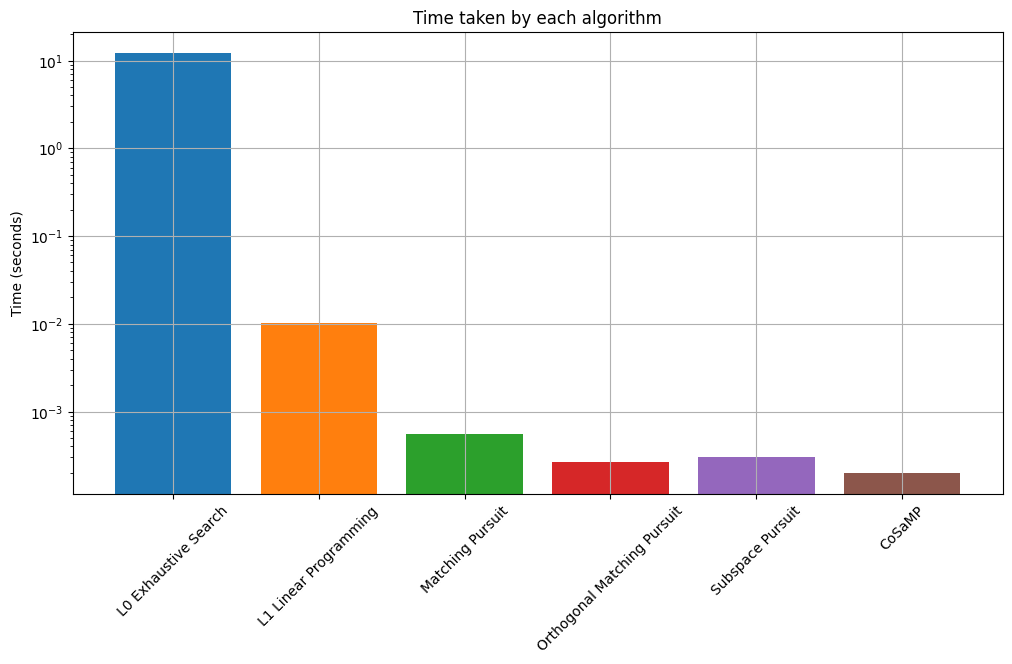

In [14]:
# We can quickly plot the time taken by each algorithm, log-scaled.
plt.figure(figsize=(12, 6))
for name, (result, time_taken) in results.items():
    plt.bar(name, time_taken)
plt.ylabel('Time (seconds)')
plt.title('Time taken by each algorithm')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Part 2

## Effectiveness of Sparse Recovery Algorithms on Synthetic Signals

Suppose that we have a signal $x$ of 256 samples ($N = 256$) where only 5 of these samples are nonzero ($S = 5$). The location and magnitude of these nonzero samples are unknown. Let’s try to see the effectiveness of various sparse recovery algorithms on this synthetic signal.

Vary the number of measurements $M$ (say $M = \{5, 10, 15, 20, 25, 30, \dots, 100\}$), and perform $L_1$-minimization as well as the four greedy pursuit algorithms over 100 different instances of the signal $x$ by varying the location and magnitude of its nonzero samples. 

Let’s say if $\|\hat{x} - x\|_2 \le 10^{-6}$, then we regard the signal recovery as perfect. Plot the performance curve in which the x-axis represents the number of measurements $M$ while the y-axis denotes the probability of perfect signal recovery. At each of the 100 instances, the signal should be different and the random sensing matrices should be different as well.

In [15]:
# Function to generate signal
def generate_signal(N, S):
    x = np.zeros(N)
    non_zero_indices = np.random.choice(N, S, replace=False)
    x[non_zero_indices] = np.random.randn(S)
    return x

# Function to generate random measurement matrix
def generate_measurement_matrix(M, N):
    return np.random.randn(M, N)

In [16]:
# Set the random seed for reproducibility
def set_random_seed(seed):
    np.random.seed(seed)

set_random_seed(42)

In [17]:
# The signal to recover
N = 256  # Signal dimension
S = 5   # Sparsity level
M_values = [i for i in range(5, 101, 5)]  # Number of measurements to test

x_list = [generate_signal(N, S) for _ in range(100)] # Generate 100 random signals
A_list = [generate_measurement_matrix(m, N) for m in M_values]

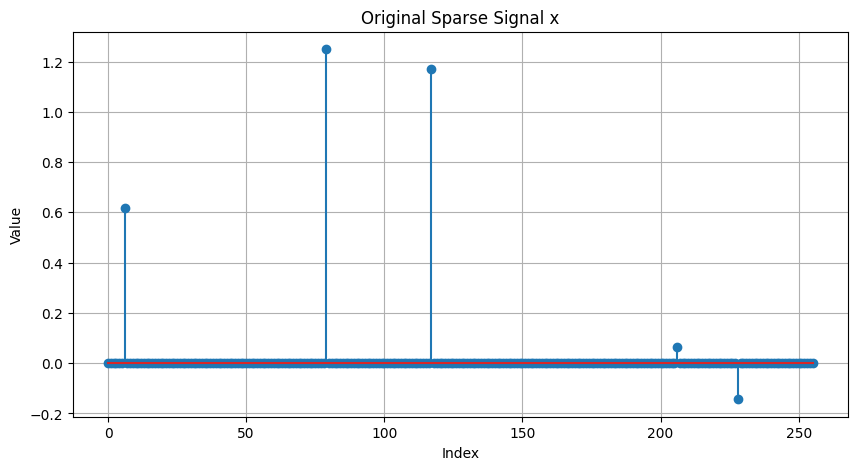

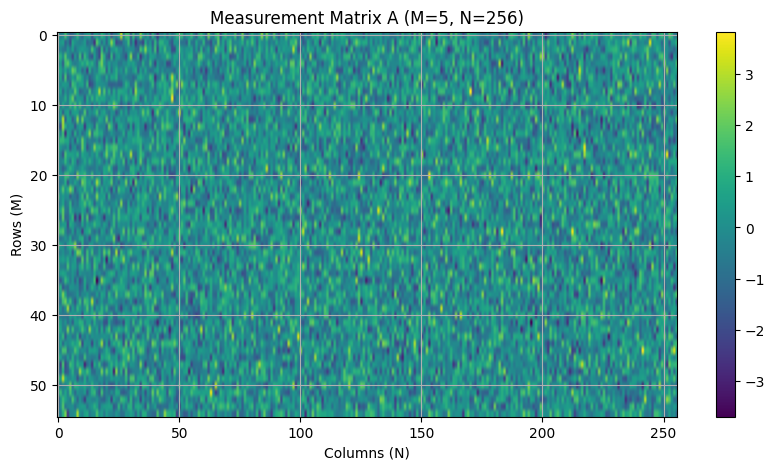

In [18]:
# Let's take a look at the original signal and the measurement matrix to understand what we are working with.
plot_solution(x_list[0], "Original Sparse Signal x")

# Let's make a function to visulalize the measurement matrix as an image to reuse, since we didn't write one in HW1
def plot_measurement_matrix(A, title):
    plt.figure(figsize=(10, 5))
    plt.imshow(A, aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title(title)
    plt.xlabel('Columns (N)')
    plt.ylabel('Rows (M)')
    plt.grid()
    plt.show()

plot_measurement_matrix(A_list[10], "Measurement Matrix A (M=5, N=256)")


In [19]:
# Function to test one algorithm on one signal and one measurement matrix, and return whether the solution is correct.
def test_algorithm_on_signal(algorithm, A, x, S, tol=1e-6):
    y = A @ x
    start_time = time.time()
    if algorithm in [solve_subspace_pursuit, solve_cosamp]:
        x_recovered = algorithm(A, y, S)
    else:
        x_recovered = algorithm(A, y)
    end_time = time.time()
    is_correct = np.linalg.norm(x - x_recovered) <= tol
    return is_correct

In [20]:
# Test the algorithms on the generated signals and measurement matrices, and collect the results.
algorithms = {
    "L1 Linear Programming": solve_l1_linear_programming,
    "Matching Pursuit": solve_matching_pursuit,
    "Orthogonal Matching Pursuit": solve_orthogonal_matching_pursuit,
    "Subspace Pursuit": solve_subspace_pursuit,
    "CoSaMP": solve_cosamp
}
algorithm_results = {
    "L1 Linear Programming": {},
    "Matching Pursuit": {},
    "Orthogonal Matching Pursuit": {},
    "Subspace Pursuit": {},
    "CoSaMP": {}
}
for A in (A_loop := tqdm(A_list)): # Using tqdm to show progress, since this might take a while.
    A_loop.set_postfix({"M": A.shape[0]})
    M = A.shape[0]
    for x in (x_loop := tqdm(x_list, leave=False)): # Using tqdm to show progress, since this might take a while.
        for name, func in algorithms.items():
            is_correct = test_algorithm_on_signal(func, A, x, S)
            algorithm_results[name][M] = algorithm_results[name].get(M, []) + [is_correct]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

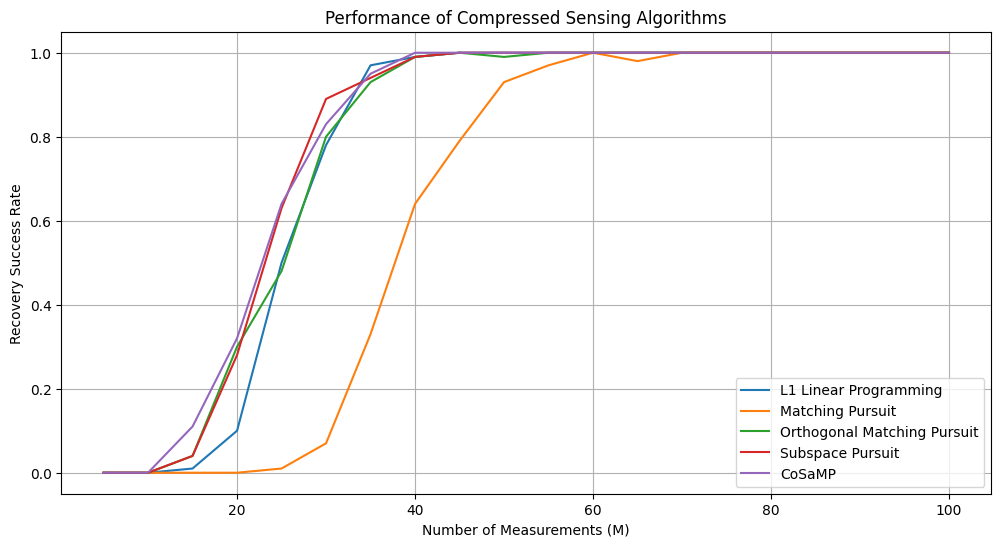

In [21]:
# Plot the recovery success rate for each algorithm as a function of the number of measurements M.
plt.figure(figsize=(12, 6))
for name, results in algorithm_results.items():
    M_values = sorted(results.keys())
    success_rates = [np.mean(results[M]) for M in M_values]
    plt.plot(M_values, success_rates, label=name)
plt.xlabel("Number of Measurements (M)")
plt.ylabel("Recovery Success Rate")
plt.title("Performance of Compressed Sensing Algorithms")
plt.legend()
plt.grid(True)
plt.show()